<a href="https://colab.research.google.com/github/ashleytegart/BCEQ/blob/main/EQ_Data_2014_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# _BC_Coast_EQs.csv uploaded as raw data from github 25/09/2024

In [355]:
# Upload csv from github

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import calendar

# Read the CSV file from GitHub
url = "https://raw.githubusercontent.com/ashleytegart/BCEQ/refs/heads/main/_BC_Coast_EQs.csv"

df = pd.read_csv(url)

# DataFrame 'df'
df.head()

,#EventID,Date,Time,Latitude,Longitude,Depth/km,MagType,Magnitude,Month,Year
0,2.023123e+07,2023-12-31,20:05:01.000Z,50.9661,-130.3944,10.00,Mw,3.08,DEC,2023
1,2.023123e+07,2023-12-29,04:53:46.000Z,53.9265,-132.4867,8.62,ML,3.88,DEC,2023
2,2.023123e+07,2023-12-26,13:03:23.000Z,48.1754,-128.7707,10.00,Mw,3.96,DEC,2023
3,2.023122e+07,2023-12-24,15:14:04.000Z,47.8197,-122.9600,52.39,ML,3.90,DEC,2023
4,2.023122e+07,2023-12-19,04:27:28.000Z,49.0129,-129.5320,10.00,Mw,3.13,DEC,2023


# Date Review and Cleaning

In [356]:
# Convert 'date' to datetime

import pandas as pd
# Convert the 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

In [357]:
# View the last 10 rows
df.tail(10)

,#EventID,Date,Time,Latitude,Longitude,Depth/km,MagType,Magnitude,Month,Year
4648,2.014011e+07,2014-01-05,23:06:32.000Z,52.6748,-132.1372,24.63,ML,3.1,JAN,2014
4649,2.014010e+07,2014-01-04,13:57:43.000Z,48.8540,-128.6000,10.00,Mw,3.1,JAN,2014
4650,2.014010e+07,2014-01-04,13:21:28.000Z,48.8371,-128.6602,10.00,Mw,3.1,JAN,2014
4651,2.014010e+07,2014-01-03,23:40:20.000Z,50.9804,-138.8849,10.00,Mw,4.3,JAN,2014
4652,2.014010e+07,2014-01-03,15:13:28.000Z,50.8809,-130.2129,10.00,Mw,3.3,JAN,2014
4653,2.014010e+07,2014-01-03,05:42:28.000Z,55.2730,-135.2162,1.00,ML,3.2,JAN,2014
4654,2.014010e+07,2014-01-02,11:21:30.000Z,47.6606,-129.2504,10.00,Mw,3.6,JAN,2014
4655,2.014010e+07,2014-01-01,20:25:38.000Z,50.8786,-129.7610,10.00,Mw,3.0,JAN,2014
4656,2.014010e+07,2014-01-01,14:18:56.000Z,50.8162,-138.9270,10.00,Mw,4.4,JAN,2014
4657,2.014010e+07,2014-01-01,13:20:58.000Z,50.4050,-130.2558,10.00,Mw,3.2,JAN,2014


In [358]:
# Make 'date' the index
df = df.set_index('Date')

# Convert month to integer
df['Month'] = df.index.month

df.head()

,#EventID,Time,Latitude,Longitude,Depth/km,MagType,Magnitude,Month,Year
Date,,,,,,,,,
2023-12-31,2.023123e+07,20:05:01.000Z,50.9661,-130.3944,10.00,Mw,3.08,12,2023
2023-12-29,2.023123e+07,04:53:46.000Z,53.9265,-132.4867,8.62,ML,3.88,12,2023
2023-12-26,2.023123e+07,13:03:23.000Z,48.1754,-128.7707,10.00,Mw,3.96,12,2023
2023-12-24,2.023122e+07,15:14:04.000Z,47.8197,-122.9600,52.39,ML,3.90,12,2023
2023-12-19,2.023122e+07,04:27:28.000Z,49.0129,-129.5320,10.00,Mw,3.13,12,2023


In [359]:
# Review data types, confirm 'Month'= integer
df.dtypes

,0
#EventID,float64
Time,object
Latitude,float64
Longitude,float64
Depth/km,float64
MagType,object
Magnitude,float64
Month,int32
Year,int64


# Data Analysis

MAGNITUDE STATISTICS: Apr, Oct are highest (Dec has highest average) / Jun, Aug has lowest

In [360]:
# MAGNITUDE AGGREGATE by MONTH and YEAR (mean, std, min, 'max')

# Group by year and month and calculate mean, std, min, max of 'Magnitude'
magnitude_agg = df.groupby([df.index.year, df.index.month])['Magnitude'].agg(['mean', 'std', 'min', 'max'])

# Rename columns for clarity
magnitude_agg = magnitude_agg.rename(columns={
    'mean': 'Mean Magnitude',
    'std': 'Std Dev Magnitude',
    'min': 'Min Magnitude',
    'max': 'Max Magnitude'
})

magnitude_agg

Mean Magnitude  Std Dev Magnitude  Min Magnitude  Max Magnitude
Date Date                                                                 
2014 1           3.330303           0.366133           3.00           4.40
     2           3.500000           0.457321           3.00           4.50
     3           3.437778           0.453917           3.00           4.60
     4           3.736782           0.599441           3.00           6.50
     5           3.400000           0.347663           3.00           4.20
...                   ...                ...            ...            ...
2023 8           3.404348           0.515062           3.01           5.17
     9           3.351286           0.362300           3.00           5.38
     10          3.592326           0.584237           3.00           5.40
     11          3.332250           0.278001           3.01           4.13
     12          3.427391           0.386208           3.03           4.73

[120 rows x 4 columns]

In [361]:
# MAGNITUDE AGGREGATE by MONTH (mean, std, min, 'max')

# Group by month and calculate mean, std, min, max of 'Magnitude'
magnitude_agg_month = df.groupby(df.index.month)['Magnitude'].agg(['mean', 'std', 'min', 'max'])

# Rename columns for clarity
magnitude_agg_month = magnitude_agg_month.rename(columns={
    'mean': 'Mean Magnitude',
    'std': 'Std Dev Magnitude',
    'min': 'Min Magnitude',
    'max': 'Max Magnitude'
})

magnitude_agg_month

,Mean Magnitude,Std Dev Magnitude,Min Magnitude,Max Magnitude
Date,,,,
1,3.479730,0.439382,3.0,5.50
2,3.449639,0.417482,3.0,5.30
3,3.371963,0.416714,3.0,5.50
4,3.467035,0.523860,3.0,6.50
5,3.416268,0.510674,3.0,6.30
6,3.333197,0.406707,3.0,5.60
7,3.436624,0.512913,3.0,6.30
8,3.383969,0.439730,3.0,5.17
9,3.377321,0.460090,3.0,6.40


In [362]:
# MAGNITUDE AGGREGATE by YEAR (mean, std, min, 'max')

# Group by year and calculate mean, std, min, max of 'Magnitude'
magnitude_agg_year = df.groupby(df.index.year)['Magnitude'].agg(['mean', 'std', 'min', 'max'])

# Rename columns for clarity
magnitude_agg_year = magnitude_agg_year.rename(columns={
    'mean': 'Mean Magnitude',
    'std': 'Std Dev Magnitude',
    'min': 'Min Magnitude',
    'max': 'Max Magnitude'
})

magnitude_agg_year

,Mean Magnitude,Std Dev Magnitude,Min Magnitude,Max Magnitude
Date,,,,
2014,3.516129,0.534980,3.0,6.50
2015,3.358723,0.417847,3.0,6.30
2016,3.335644,0.372593,3.0,5.50
2017,3.414116,0.490442,3.0,6.30
2018,3.501559,0.499841,3.0,6.50
2019,3.608287,0.626637,3.0,6.40
2020,3.430163,0.407676,3.0,5.20
2021,3.390484,0.324121,3.0,4.90
2022,3.402109,0.408101,3.0,5.33


In [363]:
# Calculate total average, min, max magnitude for all months
# Calculate total average, min, max magnitude for all years

# Calculate total average, min, max magnitude for all months
total_avg_magnitude_month = magnitude_agg_month['Mean Magnitude'].mean()
min_magnitude_month = magnitude_agg_month['Min Magnitude'].min()
max_magnitude_month = magnitude_agg_month['Max Magnitude'].max()

print("Total Average Magnitude (all months):", total_avg_magnitude_month)
print("Minimum Magnitude (all months):", min_magnitude_month)
print("Maximum Magnitude (all months):", max_magnitude_month)

# Calculate total average, min, max magnitude for all years
total_avg_magnitude_year = magnitude_agg_year['Mean Magnitude'].mean()
min_magnitude_year = magnitude_agg_year['Min Magnitude'].min()
max_magnitude_year = magnitude_agg_year['Max Magnitude'].max()

print("\nTotal Average Magnitude (all years):", total_avg_magnitude_year)
print("Minimum Magnitude (all years):", min_magnitude_year)
print("Maximum Magnitude (all years):", max_magnitude_year)

Total Average Magnitude (all months): 3.423948412801527
Minimum Magnitude (all months): 3.0
Maximum Magnitude (all months): 6.5

Total Average Magnitude (all years): 3.436507053561283
Minimum Magnitude (all years): 3.0
Maximum Magnitude (all years): 6.5


FREQUENCY STATISTICS: Dec, Jan are highest / Jun, Aug are the lowest

In [364]:
# FREQUENCY AGGREGATE by MONTH and YEAR (mean, std, min, 'max')

# Group by year, month and calculate the frequency of earthquakes
frequency_agg = df.groupby([df.index.year, df.index.month])['Magnitude'].count()

# Rename the column for clarity
frequency_agg = frequency_agg.rename('Earthquake Frequency')

# Print the results
frequency_agg

Date  Date
2014  1        33
      2        36
      3        45
      4        87
      5        24
             ... 
2023  8        23
      9       140
      10       43
      11       40
      12       23
Name: Earthquake Frequency, Length: 120, dtype: int64

In [365]:
# FREQUENCY AGGREGATE by MONTH (mean, std, min, 'max') using 'date'

# Group by month and calculate mean, std, min, max of 'Magnitude'
frequency_agg_month = df.groupby(df.index.month)['Magnitude'].agg(['count'])

# Rename columns for clarity
frequency_agg_month = frequency_agg_month.rename(columns={
    'count': 'Frequency'
})


frequency_agg_month

,Frequency
Date,
1,518
2,388
3,377
4,344
5,343
6,269
7,314
8,262
9,474


In [366]:
# FREQUENCY AGGREGATE by YEAR (mean, std, min, 'max')

# Group by year and calculate mean, std, min, max of 'Magnitude'
frequency_agg_year = df.groupby(df.index.year)['Magnitude'].agg(['count'])

# Rename columns for clarity
frequency_agg_year = frequency_agg_year.rename(columns={
    'count': 'Frequency'
})


frequency_agg_year

,Frequency
Date,
2014,496
2015,642
2016,404
2017,588
2018,449
2019,362
2020,368
2021,372
2022,403


In [367]:
# Calculate total average, min, max frequency for all months
# Calculate total average, min, max frequency for all years

# Calculate total average, min, max frequency for all months
frequency_agg_month = df.groupby(df.index.month)['Magnitude'].agg(['count'])
frequency_agg_month = frequency_agg_month.rename(columns={'count': 'Frequency'})

total_avg_frequency_month = frequency_agg_month['Frequency'].mean()
min_frequency_month = frequency_agg_month['Frequency'].min()
max_frequency_month = frequency_agg_month['Frequency'].max()

print("Total Average Frequency (all months):", total_avg_frequency_month)
print("Minimum Frequency (all months):", min_frequency_month)
print("Maximum Frequency (all months):", max_frequency_month)

# Calculate total average, min, max frequency for all years
frequency_agg_year = df.groupby(df.index.year)['Magnitude'].agg(['count'])
frequency_agg_year = frequency_agg_year.rename(columns={'count': 'Frequency'})

total_avg_frequency_year = frequency_agg_year['Frequency'].mean()
min_frequency_year = frequency_agg_year['Frequency'].min()
max_frequency_year = frequency_agg_year['Frequency'].max()

print("\nTotal Average Frequency (all years):", total_avg_frequency_year)
print("Minimum Frequency (all years):", min_frequency_year)
print("Maximum Frequency (all years):", max_frequency_year)

Total Average Frequency (all months): 388.1666666666667
Minimum Frequency (all months): 262
Maximum Frequency (all months): 562

Total Average Frequency (all years): 465.8
Minimum Frequency (all years): 362
Maximum Frequency (all years): 642


DEPTH STATISTICS: Sep to Apr trending deepest (Dec has highest average / Nov is overall highest) / May-Aug trending shallowest (Aug has lowest average and overall lowest)

In [368]:
# DEPTH/KM AGGREGATE by MONTH and YEAR (mean, std, min, 'max')

# Assuming 'df' is your DataFrame with 'Depth/km' and a datetime index
depth_agg = df.groupby([df.index.year, df.index.month])['Depth/km'].agg(['mean', 'std', 'min', 'max'])

# Rename columns for clarity
depth_agg = depth_agg.rename(columns={
    'mean': 'Mean Depth/km',
    'std': 'Std Dev Depth/km',
    'min': 'Min Depth/km',
    'max': 'Max Depth/km'
})

depth_agg

Mean Depth/km  Std Dev Depth/km  Min Depth/km  Max Depth/km
Date Date                                                             
2014 1         11.038182          6.570401          0.00         30.57
     2         10.134444          2.820421          5.00         25.09
     3          9.088000          3.871459          1.00         22.50
     4          9.959655          2.469569          1.00         23.44
     5          9.687083          3.643639          1.00         21.16
...                  ...               ...           ...           ...
2023 8          8.232174          5.297151          1.00         21.77
     9          9.786786          2.390733          1.00         21.68
     10         9.520465          9.491994          0.00         59.41
     11         8.286000          4.942768          1.00         22.89
     12        12.741739         10.286613          2.55         52.39

[120 rows x 4 columns]

In [369]:
# DEPTH/KM AGGREGATE by MONTH (mean, std, min, 'max')

# Assuming 'Depth/km' is a column in your DataFrame 'df'
depth_agg_month = df.groupby(df.index.month)['Depth/km'].agg(['mean', 'std', 'min', 'max'])

# Rename columns for clarity
depth_agg_month = depth_agg_month.rename(columns={
    'mean': 'Mean Depth',
    'std': 'Std Dev Depth',
    'min': 'Min Depth',
    'max': 'Max Depth'
})

print(depth_agg_month)

      Mean Depth  Std Dev Depth  Min Depth  Max Depth
Date                                                 
1       9.935618       4.842742        0.0      40.85
2       9.786933       4.504207        0.0      44.47
3       9.977188       4.320797        0.0      36.20
4      10.143256       4.838912        0.0      55.44
5       8.664927       5.029542        0.0      36.22
6       9.378141       5.907390        0.0      56.45
7       8.288535       5.206388        0.0      32.47
8       7.756870       4.544143        0.0      24.51
9       9.685570       4.425615        0.0      40.08
10      9.779585       5.454008        0.0      59.41
11     10.068646       6.295519        0.0      67.23
12     10.371548       5.105967        0.0      57.50


In [370]:
#DEPTH/KM AGGREGATE by YEAR (mean, std, min, 'max')

# Group by year and calculate mean, std, min, max of 'Depth/km'
depth_agg_year = df.groupby(df.index.year)['Depth/km'].agg(['mean', 'std', 'min', 'max'])

# Rename columns for clarity
depth_agg_year = depth_agg_year.rename(columns={
    'mean': 'Mean Depth/km',
    'std': 'Std Dev Depth/km',
    'min': 'Min Depth/km',
    'max': 'Max Depth/km'
})

print(depth_agg_year)

      Mean Depth/km  Std Dev Depth/km  Min Depth/km  Max Depth/km
Date                                                             
2014       9.674395          4.584186           0.0         53.90
2015      10.750950          4.650324           0.0         57.50
2016       9.871485          4.340370           1.0         55.44
2017       9.169626          5.560152           0.0         56.45
2018       9.917506          3.494888           0.0         39.32
2019      10.637210          6.098427           0.0         67.23
2020       8.444402          5.733615           0.0         38.87
2021       8.415376          5.106666           0.0         43.84
2022       9.317444          5.375945           0.0         40.08
2023       9.326028          5.211832           0.0         59.41


In [371]:
# Calculate total average, min, max depth/km for all months
# Calculate total average, min, max depth/km for all years

# Calculate total average, min, max depth/km for all months
depth_agg_month = df.groupby(df.index.month)['Depth/km'].agg(['mean', 'min', 'max'])
total_avg_depth_month = depth_agg_month['mean'].mean()
min_depth_month = depth_agg_month['min'].min()
max_depth_month = depth_agg_month['max'].max()

print("Total Average Depth/km (all months):", total_avg_depth_month)
print("Minimum Depth/km (all months):", min_depth_month)
print("Maximum Depth/km (all months):", max_depth_month)

# Calculate total average, min, max depth/km for all years
depth_agg_year = df.groupby(df.index.year)['Depth/km'].agg(['mean', 'min', 'max'])
total_avg_depth_year = depth_agg_year['mean'].mean()
min_depth_year = depth_agg_year['min'].min()
max_depth_year = depth_agg_year['max'].max()

print("\nTotal Average Depth/km (all years):", total_avg_depth_year)
print("Minimum Depth/km (all years):", min_depth_year)
print("Maximum Depth/km (all years):", max_depth_year)

Total Average Depth/km (all months): 9.486401450893082
Minimum Depth/km (all months): 0.0
Maximum Depth/km (all months): 67.23

Total Average Depth/km (all years): 9.552442238988668
Minimum Depth/km (all years): 0.0
Maximum Depth/km (all years): 67.23


# Plotting and Graphs

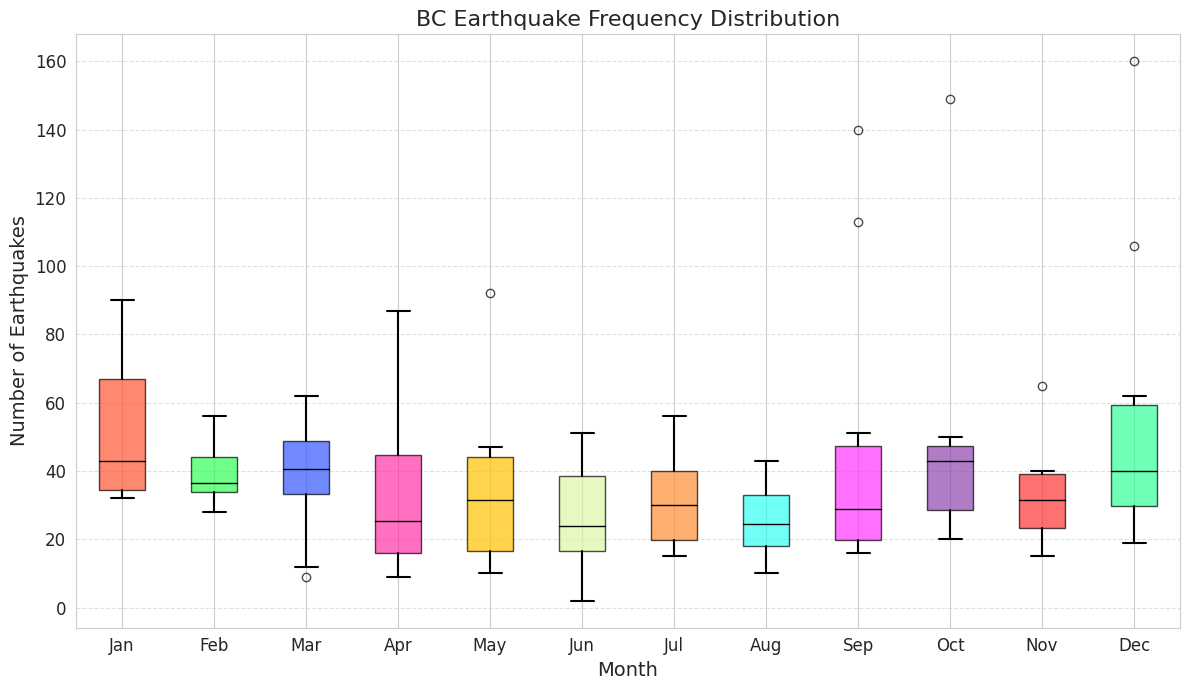

Plot saved as PNG and PDF in Google Drive: 
- /content/drive/My Drive/BC_Earthquake_Frequency_Distribution.png 
- /content/drive/My Drive/BC_Earthquake_Frequency_Distribution.pdf


In [372]:
# Univariate Boxplot showing distribution of earthquakes via months
import pandas as pd
import matplotlib.pyplot as plt

# Load the earthquake data from the URL
url = "https://raw.githubusercontent.com/ashleytegart/BCEQ/refs/heads/main/_BC_Coast_EQs.csv"
data = pd.read_csv(url)

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract the month and year from the 'Date' column
data['Month'] = data['Date'].dt.month  # Extract month as a number (1-12)
data['Year'] = data['Date'].dt.year    # Extract year

# Count the number of earthquakes per month across all years
monthly_counts = data.groupby(['Year', 'Month']).size().reset_index(name='Count')

# Define custom colors for each month
box_colors = {
    1: '#FF5733',   # January (bright orange-red)
    2: '#33FF57',   # February (vivid green)
    3: '#3357FF',   # March (bright blue)
    4: '#FF33A6',   # April (vivid pink)
    5: '#FFC300',   # May (bright yellow)
    6: '#DAF7A6',   # June (soft green-yellow)
    7: '#FF8D33',   # July (orange)
    8: '#33FFF3',   # August (cyan)
    9: '#FF33FF',   # September (magenta)
    10: '#8E44AD',  # October (purple)
    11: '#FF3333',  # November (red)
    12: '#33FF99'   # December (bright mint)
}

# Create a figure for the boxplot
plt.figure(figsize=(12, 7))

# Create boxplot with custom colors
boxplot = plt.boxplot([monthly_counts[monthly_counts['Month'] == i]['Count'] for i in range(1, 13)],
                      labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
                      patch_artist=True,  # Enables color fill
                      medianprops=dict(color='black'))  # Set median line color

# Customizing each box's appearance
for i, patch in enumerate(boxplot['boxes']):
    patch.set_facecolor(box_colors[i + 1])  # Set color based on the month
    patch.set_edgecolor('black')  # Box edge color
    patch.set_alpha(0.7)  # Transparency level

# Customizing the whiskers
for whisker in boxplot['whiskers']:
    whisker.set(color='black', linewidth=1.5)

# Customizing the caps
for cap in boxplot['caps']:
    cap.set(color='black', linewidth=1.5)

# Customizing the outliers to match the month colors
for i, flier in enumerate(boxplot['fliers']):
    month_color = box_colors[i + 1]  # Get the corresponding month color
    flier.set(marker='o', color=month_color, alpha=0.7)  # Set outlier color

# Set the title and labels with custom font sizes
plt.title('BC Earthquake Frequency Distribution', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Earthquakes', fontsize=14)

# Add grid lines only for the y-axis
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Tight layout for better spacing
plt.tight_layout()

# Save the plot as PNG and PDF
png_path = '/content/drive/My Drive/BC_Earthquake_Frequency_Distribution.png'
pdf_path = '/content/drive/My Drive/BC_Earthquake_Frequency_Distribution.pdf'
plt.savefig(png_path, format='png')
plt.savefig(pdf_path, format='pdf')

# Show the plot
plt.show()

# Print confirmation
print(f"Plot saved as PNG and PDF in Google Drive: \n- {png_path} \n- {pdf_path}")

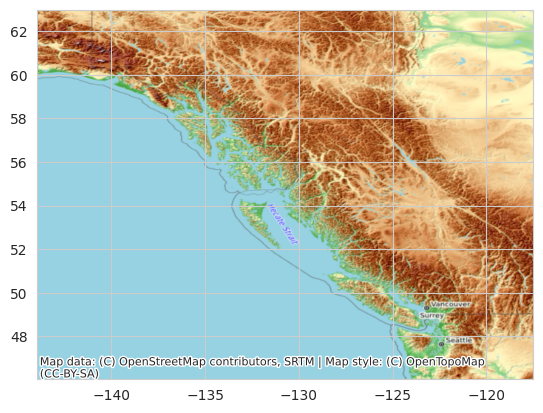

In [373]:
# For basemap: pip install contextily
!pip install contextily

# Add basemap
import matplotlib.pyplot as plt
import contextily as ctx

# Add basemap
# Convert the coordinates to Web Mercator format
ax = plt.gca()
ax.set_xlim(data['Longitude'].min() - 1, data['Longitude'].max() + 1)
ax.set_ylim(data['Latitude'].min() - 1, data['Latitude'].max() + 1)

# Use a different tile provider, like OpenTopoMap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenTopoMap) # Changed Stamen.Terrain to OpenTopoMap

# Display the plot
plt.show()

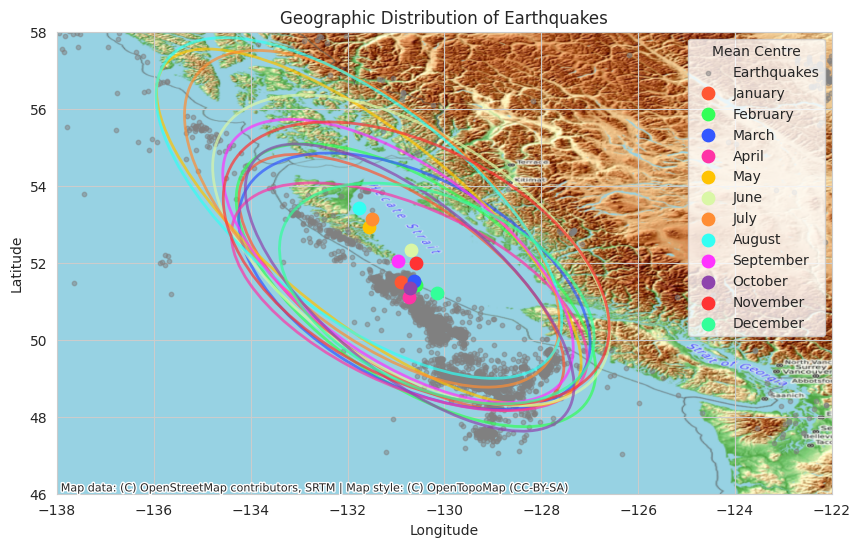

Plot saved as PNG and PDF in Google Drive: 
- /content/drive/My Drive/Geographic_Distribution.png 
- /content/drive/My Drive/Geographic_Distribution.pdf


In [374]:
# Scatterplot: Put the plot with the basemap and customize.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
import contextily as ctx

# Load your data
url = "https://raw.githubusercontent.com/ashleytegart/BCEQ/refs/heads/main/_BC_Coast_EQs.csv"
data = pd.read_csv(url)

# Convert 'Date' column to datetime format if it's not already
data['Date'] = pd.to_datetime(data['Date'])

# Extract month from the date
data['Month'] = data['Date'].dt.month

# Group by month and calculate mean latitude and longitude for each month
mean_centers = data.groupby('Month').agg({'Latitude': 'mean', 'Longitude': 'mean'}).reset_index()

# Define color mapping for each month
month_colors = {
    1: '#FF5733',   # January (bright orange-red)
    2: '#33FF57',   # February (vivid green)
    3: '#3357FF',   # March (bright blue)
    4: '#FF33A6',   # April (vivid pink)
    5: '#FFC300',   # May (bright yellow)
    6: '#DAF7A6',   # June (soft green-yellow)
    7: '#FF8D33',   # July (orange)
    8: '#33FFF3',   # August (cyan)
    9: '#FF33FF',   # September (magenta)
    10: '#8E44AD',  # October (purple)
    11: '#FF3333',  # November (red)
    12: '#33FF99'   # December (bright mint)
}

# Create a legend label for each month
legend_labels = {month: f"{pd.to_datetime(f'2021-{month}-01').strftime('%B')}" for month in month_colors.keys()}

# Create a plot
plt.figure(figsize=(10, 6))

# Scatter plot of all earthquakes in light grey circles
plt.scatter(data['Longitude'], data['Latitude'], color='grey', s=10, alpha=0.5, label='Earthquakes')

# Plot mean centers for each month and add ellipses
for month, color in month_colors.items():
    # Get the data for the current month
    month_data = data[data['Month'] == month]

    # Calculate mean coordinates for the current month
    mean_lat = month_data['Latitude'].mean()
    mean_lon = month_data['Longitude'].mean()

    # Calculate the covariance matrix and the eigenvalues/eigenvectors
    cov_matrix = np.cov(month_data['Longitude'], month_data['Latitude'])
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    # Calculate the angle of the ellipse
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * 180 / np.pi  # Convert to degrees

    # Create an ellipse
    width, height = 2 * np.sqrt(eigenvalues)  # Width and height of the ellipse
    ellipse = Ellipse(xy=(mean_lon, mean_lat), width=width, height=height,
                      angle=angle, facecolor='none', edgecolor=color, alpha=0.7, linewidth=2)

    # Add the ellipse to the plot
    plt.gca().add_patch(ellipse)

    # Plot the mean center for the month
    plt.scatter(mean_lon, mean_lat, color=color, s=80, marker='o', label=legend_labels[month])

# Set the labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Earthquakes')

# Display the legend
plt.legend(title='Mean Centre', loc='upper right')

# Set the longitude and latitude limits to zoom in
plt.xlim(-138, -122)  # Longitude limits
plt.ylim(46, 58)      # Latitude limits

# Add basemap
# Get current axis
ax = plt.gca()
# Add the basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenTopoMap)

# Save the plot as PNG and PDF
png_path = '/content/drive/My Drive/Geographic_Distribution.png'
pdf_path = '/content/drive/My Drive/Geographic_Distribution.pdf'
plt.savefig(png_path, format='png')
plt.savefig(pdf_path, format='pdf')

# Display the plot
plt.show()

# Print confirmation
print(f"Plot saved as PNG and PDF in Google Drive: \n- {png_path} \n- {pdf_path}")

MEAN CENTRE: all mean centres clustered around 51 to 54 latitude / -133 to -131 longitude. September to March mean centres are close together.

In [375]:
# Statistics from Mean Centre of Earthquakes by Month

# Calculate mean latitude and longitude for each month
mean_centers = df.groupby('Month').agg({'Latitude': 'mean', 'Longitude': 'mean'}).reset_index()

# Add month names for better readability
mean_centers['Month_Name'] = mean_centers['Month'].apply(lambda x: calendar.month_name[x])

# Print the mean centers with month names
print("Mean Center of Earthquakes by Month:")
print(mean_centers[['Month_Name', 'Latitude', 'Longitude']])

# Calculate descriptive statistics for latitude and longitude by month
latitude_stats = df.groupby('Month')['Latitude'].agg(['mean', 'std', 'min', 'max'])
longitude_stats = df.groupby('Month')['Longitude'].agg(['mean', 'std', 'min', 'max'])

# Print the latitude statistics by month
print("\nLatitude Statistics by Month:")
print(latitude_stats)

# Print the longitude statistics by month
print("\nLongitude Statistics by Month:")
print(longitude_stats)

Mean Center of Earthquakes by Month:
   Month_Name   Latitude   Longitude
0     January  51.490875 -130.888230
1    February  51.416754 -130.586485
2       March  51.518922 -130.619132
3       April  51.116270 -130.723882
4         May  52.922582 -131.560467
5        June  52.321416 -130.685108
6        July  53.141437 -131.495211
7      August  53.421352 -131.765568
8   September  52.046782 -130.958055
9     October  51.353906 -130.717568
10   November  51.987355 -130.581148
11   December  51.200598 -130.156314

Latitude Statistics by Month:
            mean       std      min      max
Month                                       
1      51.490875  3.323658  47.5194  61.9577
2      51.416754  3.676159  47.2473  61.9608
3      51.518922  3.331476  47.4898  61.9920
4      51.116270  2.957731  47.1175  61.7435
5      52.922582  4.628898  47.3657  61.5663
6      52.321416  4.033816  47.0476  61.6249
7      53.141437  4.372939  47.4383  61.9647
8      53.421352  4.424648  47.4950  61.5998
9

STANDARD DEVIATIONAL ELLIPSE: May, June, July and August have more NW distribution

In [376]:
# Statistics from Standard Deviational Ellipse of Earthquakes by Month

import pandas as pd
import numpy as np
# Assuming 'data' is your DataFrame with 'Latitude' and 'Longitude' columns
# Convert 'Date' column to datetime format if it's not already
data['Date'] = pd.to_datetime(data['Date'])

# Extract month from the date
data['Month'] = data['Date'].dt.month

for month in data['Month'].unique():
  # Filter data for the current month
  month_data = data[data['Month'] == month]

  # Calculate mean latitude and longitude
  mean_latitude = month_data['Latitude'].mean()
  mean_longitude = month_data['Longitude'].mean()

  # Calculate the covariance matrix for latitude and longitude
  cov_matrix = np.cov(month_data['Longitude'], month_data['Latitude'])

  # Calculate eigenvalues and eigenvectors of the covariance matrix
  eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

  # Calculate the standard deviation ellipse parameters
  width = 2 * np.sqrt(eigenvalues[0])
  height = 2 * np.sqrt(eigenvalues[1])
  angle = np.arctan2(*eigenvectors[:, 0][::-1]) * 180 / np.pi

  print(f"Month: {month}, Month Name: {calendar.month_name[month]}")
  print(f"  Mean Latitude: {mean_latitude:.2f}")
  print(f"  Mean Longitude: {mean_longitude:.2f}")
  print(f"  Standard Deviation Ellipse Width: {width:.2f}")
  print(f"  Standard Deviation Ellipse Height: {height:.2f}")
  print(f"  Standard Deviation Ellipse Angle (degrees): {angle:.2f}")

Month: 12, Month Name: December
  Mean Latitude: 51.20
  Mean Longitude: -130.16
  Standard Deviation Ellipse Width: 7.31
  Standard Deviation Ellipse Height: 4.66
  Standard Deviation Ellipse Angle (degrees): -36.46
Month: 11, Month Name: November
  Mean Latitude: 51.99
  Mean Longitude: -130.58
  Standard Deviation Ellipse Width: 9.27
  Standard Deviation Ellipse Height: 5.61
  Standard Deviation Ellipse Angle (degrees): -39.89
Month: 10, Month Name: October
  Mean Latitude: 51.35
  Mean Longitude: -130.72
  Standard Deviation Ellipse Width: 3.98
  Standard Deviation Ellipse Height: 9.27
  Standard Deviation Ellipse Angle (degrees): -138.94
Month: 9, Month Name: September
  Mean Latitude: 52.05
  Mean Longitude: -130.96
  Standard Deviation Ellipse Width: 4.53
  Standard Deviation Ellipse Height: 9.27
  Standard Deviation Ellipse Angle (degrees): -135.79
Month: 8, Month Name: August
  Mean Latitude: 53.42
  Mean Longitude: -131.77
  Standard Deviation Ellipse Width: 5.00
  Standard D

# Google Earth Engine

GoogleEarthEngine dataset [ERA5 Daily Aggregates](https://code.earthengine.google.com/8cf469aae4be29e8f98a088b58a8f245)  

In [377]:
#Google Earth Engine BCEQs: project#:505580913535 / project id:bceq-ashleydtegart
import ee
ee.Authenticate()
ee.Initialize(project='505580913535')

In [378]:
#Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [379]:
# Import: ERA5 Daily Aggregates - Latest Climate Reanalysis Produced by ECMWF / Copernicus Climate Change Service
ET = ee.ImageCollection("ECMWF/ERA5/DAILY")
ET.first().getInfo()

{'type': 'Image',
 'bands': [{'id': 'mean_2m_air_temperature',
   'data_type': {'type': 'PixelType', 'precision': 'float'},
   'dimensions': [1440, 721],
   'crs': 'EPSG:4326',
   'crs_transform': [0.25, 0, -180, 0, -0.25, 90]},
  {'id': 'minimum_2m_air_temperature',
   'data_type': {'type': 'PixelType', 'precision': 'float'},
   'dimensions': [1440, 721],
   'crs': 'EPSG:4326',
   'crs_transform': [0.25, 0, -180, 0, -0.25, 90]},
  {'id': 'maximum_2m_air_temperature',
   'data_type': {'type': 'PixelType', 'precision': 'float'},
   'dimensions': [1440, 721],
   'crs': 'EPSG:4326',
   'crs_transform': [0.25, 0, -180, 0, -0.25, 90]},
  {'id': 'dewpoint_2m_temperature',
   'data_type': {'type': 'PixelType', 'precision': 'float'},
   'dimensions': [1440, 721],
   'crs': 'EPSG:4326',
   'crs_transform': [0.25, 0, -180, 0, -0.25, 90]},
  {'id': 'total_precipitation',
   'data_type': {'type': 'PixelType', 'precision': 'float'},
   'dimensions': [1440, 721],
   'crs': 'EPSG:4326',
   'crs_trans

In [380]:
# Reduce the image collection to mean_2m_air_temperature
ET = ee.ImageCollection("ECMWF/ERA5/DAILY")

ET_temp = ET.select('mean_2m_air_temperature')

# Filter mean_2m_air_temperature to timerange--> Start @ 2013.01.01 and stop @ 2023.12.31 (10 years)
start_date = '2014-01-01'
end_date = '2023-12-31'

ET_temp_timerange = ET_temp.filterDate(start_date, end_date)

ET_temp.first().bandNames().getInfo()

['mean_2m_air_temperature']

In [381]:
# Mean 2mt for months
import ee

# Initialize the Earth Engine module.
ee.Initialize()

# Define the Mean 2m air temperature ImageCollection and select mean air temperature band.
ET = ee.ImageCollection("ECMWF/ERA5/DAILY")
ET_temp = ET.select('mean_2m_air_temperature')

# Define the start and stop date for the 10-year period.
start = '2014-01-31'
stop = '2023-12-31'

# Filter the collection by the date range.
ET_temp_timerange = ET_temp.filterDate(start, stop)

# Define the region of interest: Latitude 47° to 62° and Longitude -143° to -118°.
region_of_interest = ee.Geometry.Polygon([
    [[-143, 47], [-143, 62], [-118, 62], [-118, 47], [-143, 47]]
])

# Function to compute the mean for a specific month across all years
def compute_mean_for_month(month):
    # Create a time filter for the specific month across all years.
    filtered_by_month = ET_temp_timerange.filter(ee.Filter.calendarRange(month, month, 'month'))

    # Calculate the mean for the specific month across all years.
    monthly_mean = filtered_by_month.mean().set('month', month)

    # Compute the mean for the specific region (Latitude 47° to 62°, Longitude -143° to -118°).
    regional_mean = monthly_mean.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region_of_interest,  # Region of interest
        scale=1000,
        maxPixels=1e9
    )

    # Get the mean ST value for the region.
    # Changed regional_mean.get('2mt') to regional_mean.get('mean_2m_air_temperature')
    return ee.Feature(None, {'month': month, 'mean_2mt': regional_mean.get('mean_2m_air_temperature')})

# List of months (1 to 12).
months = ee.List.sequence(1, 12)

# Map over the months to compute the monthly means for the 10-year period and get the regional means.
monthly_mean_values = ee.FeatureCollection(months.map(lambda m: compute_mean_for_month(ee.Number(m))))

# Get the results as a list of dictionaries with month and mean SST values.
mean_2mt_list = monthly_mean_values.reduceColumns(ee.Reducer.toList(2), ['month', 'mean_2mt']).get('list')

# Print the result of mean ST values for each month.
mean_2mt_list_values = mean_2mt_list.getInfo()

# Output the results.
for value in mean_2mt_list_values:
    month = value[0]
    mean_2mt = value[1]
    print(f"Month: {int(month)}, Mean 2MT: {mean_2mt}")

Month: 1, Mean 2MT: 269.3245307020488
Month: 2, Mean 2MT: 268.73829894448716
Month: 3, Mean 2MT: 271.9748295553707
Month: 4, Mean 2MT: 276.39714255565013
Month: 5, Mean 2MT: 281.3983625660366
Month: 6, Mean 2MT: 284.1435115783686
Month: 7, Mean 2MT: 286.64047688957993
Month: 8, Mean 2MT: 286.67195243461515
Month: 9, Mean 2MT: 283.02859203169845
Month: 10, Mean 2MT: 278.50965271944
Month: 11, Mean 2MT: 272.88633685238864
Month: 12, Mean 2MT: 269.6698587320132


In [382]:
# Convert Meant 2MT from K to Celsius
for value in mean_2mt_list_values:
    month = value[0]
    mean_2mt_kelvin = value[1]
    mean_2mt_celsius = mean_2mt_kelvin - 273.15  # Convert Kelvin to Celsius
    print(f"Month: {int(month)}, Mean 2MT (Celsius): {mean_2mt_celsius}")

Month: 1, Mean 2MT (Celsius): -3.8254692979512015
Month: 2, Mean 2MT (Celsius): -4.411701055512822
Month: 3, Mean 2MT (Celsius): -1.1751704446292592
Month: 4, Mean 2MT (Celsius): 3.247142555650157
Month: 5, Mean 2MT (Celsius): 8.248362566036633
Month: 6, Mean 2MT (Celsius): 10.993511578368611
Month: 7, Mean 2MT (Celsius): 13.490476889579952
Month: 8, Mean 2MT (Celsius): 13.521952434615173
Month: 9, Mean 2MT (Celsius): 9.878592031698474
Month: 10, Mean 2MT (Celsius): 5.359652719440021
Month: 11, Mean 2MT (Celsius): -0.26366314761133935
Month: 12, Mean 2MT (Celsius): -3.4801412679867667


In [383]:
import pandas as pd

# Create a Pandas DataFrame from the mean_2mt_list_values
mean_2mt_df = pd.DataFrame(mean_2mt_list_values, columns=['Month', 'Mean_2MT_Kelvin'])

# Convert 'Month' to integer
mean_2mt_df['Month'] = mean_2mt_df['Month'].astype(int)

# Convert 'Mean_2MT_Kelvin' to numeric
mean_2mt_df['Mean_2MT_Kelvin'] = pd.to_numeric(mean_2mt_df['Mean_2MT_Kelvin'])

# Calculate Mean_2MT_Celsius
mean_2mt_df['Mean_2MT_Celsius'] = mean_2mt_df['Mean_2MT_Kelvin'] - 273.15

# Assuming 'df' is the original DataFrame and 'Month' column is already numeric
# No need to convert 'Month' column using month_mapping

# Merge with the existing DataFrame based on the numeric 'Month' column
merged_df = pd.merge(df, mean_2mt_df, on='Month', how='left')

# Display the merged DataFrame
print(merged_df)

          #EventID           Time  Latitude  Longitude  Depth/km MagType  \
0     2.023123e+07  20:05:01.000Z   50.9661  -130.3944     10.00      Mw   
1     2.023123e+07  04:53:46.000Z   53.9265  -132.4867      8.62      ML   
2     2.023123e+07  13:03:23.000Z   48.1754  -128.7707     10.00      Mw   
3     2.023122e+07  15:14:04.000Z   47.8197  -122.9600     52.39      ML   
4     2.023122e+07  04:27:28.000Z   49.0129  -129.5320     10.00      Mw   
...            ...            ...       ...        ...       ...     ...   
4653  2.014010e+07  05:42:28.000Z   55.2730  -135.2162      1.00      ML   
4654  2.014010e+07  11:21:30.000Z   47.6606  -129.2504     10.00      Mw   
4655  2.014010e+07  20:25:38.000Z   50.8786  -129.7610     10.00      Mw   
4656  2.014010e+07  14:18:56.000Z   50.8162  -138.9270     10.00      Mw   
4657  2.014010e+07  13:20:58.000Z   50.4050  -130.2558     10.00      Mw   

      Magnitude  Month  Year  Mean_2MT_Kelvin  Mean_2MT_Celsius  
0          3.08     1

In [384]:
merged_df

,#EventID,Time,Latitude,Longitude,Depth/km,MagType,Magnitude,Month,Year,Mean_2MT_Kelvin,Mean_2MT_Celsius
0,2.023123e+07,20:05:01.000Z,50.9661,-130.3944,10.00,Mw,3.08,12,2023,269.669859,-3.480141
1,2.023123e+07,04:53:46.000Z,53.9265,-132.4867,8.62,ML,3.88,12,2023,269.669859,-3.480141
2,2.023123e+07,13:03:23.000Z,48.1754,-128.7707,10.00,Mw,3.96,12,2023,269.669859,-3.480141
3,2.023122e+07,15:14:04.000Z,47.8197,-122.9600,52.39,ML,3.90,12,2023,269.669859,-3.480141
4,2.023122e+07,04:27:28.000Z,49.0129,-129.5320,10.00,Mw,3.13,12,2023,269.669859,-3.480141
...,...,...,...,...,...,...,...,...,...,...,...
4653,2.014010e+07,05:42:28.000Z,55.2730,-135.2162,1.00,ML,3.20,1,2014,269.324531,-3.825469
4654,2.014010e+07,11:21:30.000Z,47.6606,-129.2504,10.00,Mw,3.60,1,2014,269.324531,-3.825469
4655,2.014010e+07,20:25:38.000Z,50.8786,-129.7610,10.00,Mw,3.00,1,2014,269.324531,-3.825469
4656,2.014010e+07,14:18:56.000Z,50.8162,-138.9270,10.00,Mw,4.40,1,2014,269.324531,-3.825469


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


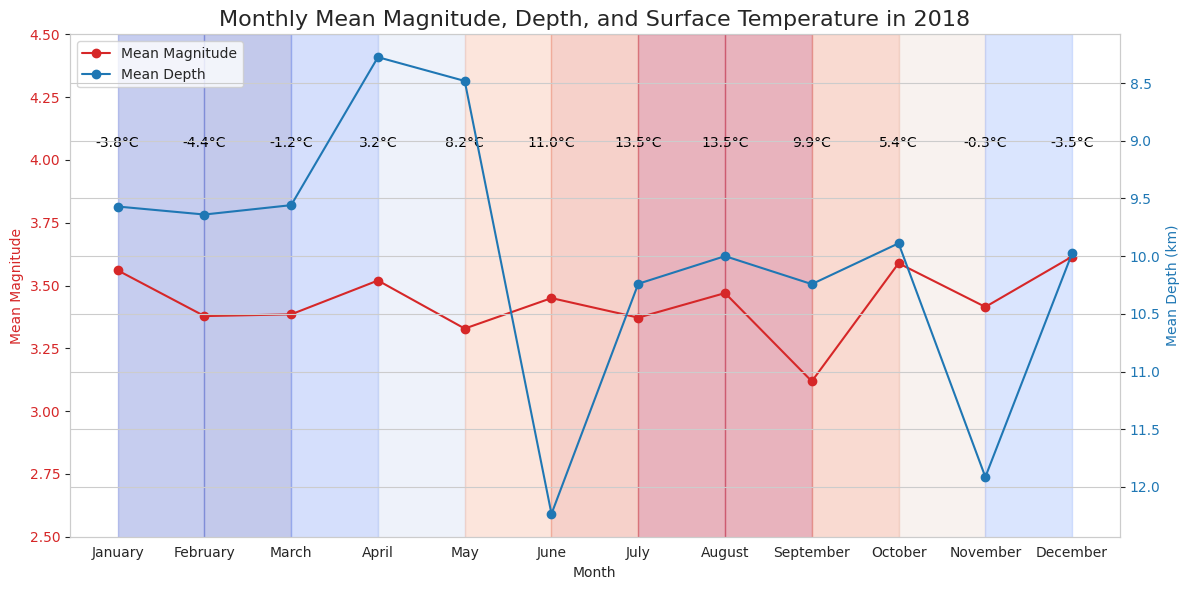

In [385]:
# Timeseries Plot - 2018 with mean surface temp, magnitude, and depth/km
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Filter the merged_df for the year 2018
merged_df['Date'] = pd.to_datetime(merged_df['Year'].astype(str) + '-' + merged_df['Month'].astype(str).str.zfill(2) + '-01')
df_2018 = merged_df[merged_df['Date'].dt.year == 2018]

# Group the data by month and calculate the mean for each required column
monthly_data = df_2018.groupby(df_2018['Date'].dt.month).agg({
    'Magnitude': 'mean',
    'Depth/km': 'mean',
    'Mean_2MT_Celsius': 'mean'
}).reset_index()

# Create month names for x-axis labels
monthly_data['Month'] = monthly_data['Date'].apply(lambda x: calendar.month_name[x])

# Create a figure with shared x-axis for months
fig, ax1 = plt.subplots(figsize=(12, 6))

# Define colors
depth_color = 'tab:blue'
magnitude_color = 'tab:red'

# Plot mean magnitude
ax1.set_xlabel('Month')
ax1.set_ylabel('Mean Magnitude', color=magnitude_color)
ax1.plot(monthly_data['Month'], monthly_data['Magnitude'], color=magnitude_color, marker='o', label='Mean Magnitude', zorder=2)
ax1.tick_params(axis='y', labelcolor=magnitude_color)

# Set y-axis limits for Mean Magnitude
ax1.set_ylim(2.5, 4.5)

# Create a second y-axis for mean depth
ax2 = ax1.twinx()
ax2.set_ylabel('Mean Depth (km)', color=depth_color)
ax2.plot(monthly_data['Month'], monthly_data['Depth/km'], color=depth_color, marker='o', label='Mean Depth', zorder=2)
ax2.tick_params(axis='y', labelcolor=depth_color)

# Invert the y-axis for depth
ax2.invert_yaxis()

# Create a colormap based on Mean Surface Temperature
norm = plt.Normalize(monthly_data['Mean_2MT_Celsius'].min(), monthly_data['Mean_2MT_Celsius'].max())
cmap = plt.cm.coolwarm

# Fill the background based on the mean surface temperature
for i in range(len(monthly_data) - 1):
    ax1.fill_betweenx([0, ax1.get_ylim()[1]],
                      monthly_data['Month'][i],
                      monthly_data['Month'][i + 1],
                      color=cmap(norm(monthly_data['Mean_2MT_Celsius'][i])),
                      alpha=0.3)

# Add mean temperature text on background
for i in range(len(monthly_data)):
    ax1.text(monthly_data['Month'][i], ax1.get_ylim()[1] * 0.9, f"{monthly_data['Mean_2MT_Celsius'][i]:.1f}°C",
             horizontalalignment='center', color='black', fontsize=10)

# Add title
plt.title('Monthly Mean Magnitude, Depth, and Surface Temperature in 2018', fontsize=16)

# Remove all grid lines
ax1.grid(False)  # Disable grid lines entirely

# Add legends for both y-values
lines = ax1.get_lines() + ax2.get_lines()
labels = ['Mean Magnitude', 'Mean Depth']
ax1.legend(lines, labels, loc='upper left')

# Adjust layout
plt.tight_layout()

# Save the plot as PNG and PDF in Google Drive
plt.savefig('/content/drive/My Drive/monthly_mean_magnitude_depth_surface_temp_2018.png', dpi=300)
plt.savefig('/content/drive/My Drive/monthly_mean_magnitude_depth_surface_temp_2018.pdf')

# Show the plot
plt.show()
